In [12]:
from sklearn.datasets import make_regression
import numpy as np
import pandas as pd


X, y, coef = make_regression(
    n_samples=100,
    n_features=1,
    noise=20,
    coef=True,
    bias=50,
    random_state=42
)

X_scaled = (X - X.min()) / (X.max() - X.min()) * 100
X_scaled = X_scaled.flatten()   

y_scaled = coef * X_scaled + 50 + np.random.RandomState(42).randn(100) * 20

df = pd.DataFrame({'Marketing_Spend': X_scaled, 'Sales': y_scaled})

print("Synthetic Data Generated (first 5 rows):")
print(df.head())
print(f"\nTrue coefficient used: {coef:.2f}")


Synthetic Data Generated (first 5 rows):
   Marketing_Spend        Sales
0        79.405338  3374.400476
1        60.527238  2573.708221
2        34.929026  1520.929747
3        65.607718  2818.998944
4        47.865826  2043.289159

True coefficient used: 41.74


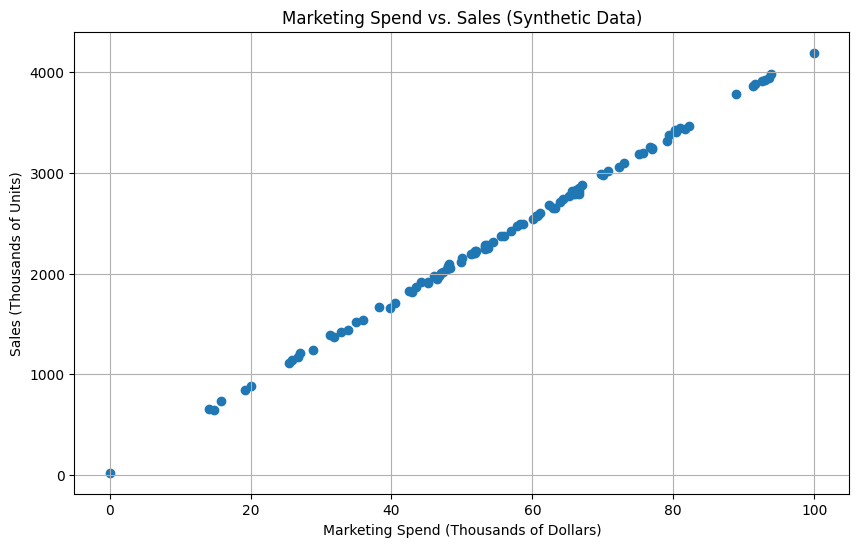

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Marketing_Spend'], df['Sales'])
plt.title('Marketing Spend vs. Sales (Synthetic Data)')
plt.xlabel('Marketing Spend (Thousands of Dollars)')
plt.ylabel('Sales (Thousands of Units)')
plt.grid(True)
plt.show()

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

X_for_model = X_scaled.reshape(-1, 1)   
y_for_model = y_scaled                   


X_train, X_test, y_train, y_test = train_test_split(
    X_for_model, y_for_model, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression Model Trained.")
print(f"Intercept: {model.intercept_:.2f}")
print(f"Coefficient (Marketing Spend): {model.coef_[0]:.2f}")

Linear Regression Model Trained.
Intercept: 48.00
Coefficient (Marketing Spend): 41.73


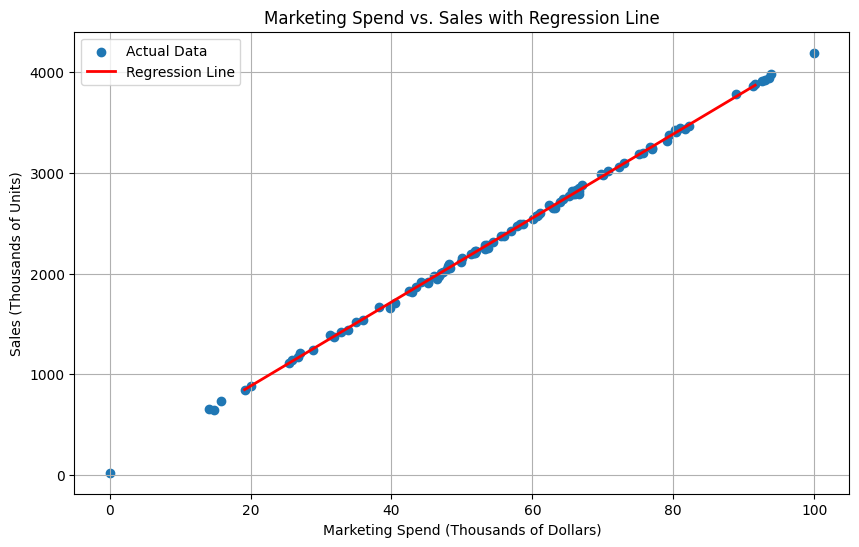

R-squared: 0.99964173
Mean Squared Error (MSE): 250.37


In [26]:
y_pred = model.predict(X_test)

sort_idx = X_test.flatten().argsort()
X_test_sorted = X_test[sort_idx]
y_pred_sorted = y_pred[sort_idx]


plt.figure(figsize=(10, 6))
plt.scatter(df['Marketing_Spend'], df['Sales'], label='Actual Data')
plt.plot(X_test_sorted, y_pred_sorted, color='red', linewidth=2, label='Regression Line')
plt.title('Marketing Spend vs. Sales with Regression Line')
plt.xlabel('Marketing Spend (Thousands of Dollars)')
plt.ylabel('Sales (Thousands of Units)')
plt.grid(True)
plt.legend()
plt.show()

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R-squared: {r2:.8f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")